# YOLO11-S + AG×2 (FPN Skips) + 2×CBAM (P4 + P5)
**Architecture:** Attention Gates on P4/P3 skip connections + CBAM at P4 and P5 outputs. No SPPF attention, no P3 CBAM.
**Motivation:** AG gates suppress haze before neck fusion; P4+P5 CBAMs refine at detection scales without P3 recall risk.
**Goal:** Early smoke/fire detection — minimize PyroNear FP rate while preserving recall
**Datasets:** D-Fire + NEMO + PyroNear (pyro-sdis) → unified ~55,698 images
**Weight init:** Cold start from factory `yolo11s.pt` — no local checkpoint transfer


---
## 1. Setup

In [1]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
import cv2

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.8 MB/s eta 0:00:00
Torch       : 2.10.0+cu128
CUDA        : True
Device      : Tesla T4
Libraries loaded ✅


---
## 2. D-Fire — Load, Filter & Verify

In [2]:
DFIRE_PATH  = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
CLASS_NAMES = ["smoke", "fire"]

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        lbls = list(lbl_dir.glob("*.txt"))
        print(f"D-Fire {split:5s}: {len(imgs):6d} images | {len(lbls):6d} labels")
    else:
        print(f"D-Fire {split}: path not found")

D-Fire train:  14122 images |  14122 labels
D-Fire val  :   3099 images |   3099 labels
D-Fire test :   4306 images |   4306 labels


In [3]:
def is_distant_shot(label_path, max_box_area=0.40):
    lbl = Path(label_path)
    if not lbl.exists():
        return True
    with open(lbl) as f:
        lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines):
        return True
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area:
            return False
    return True

print("Filtering D-Fire (max box area = 40%)...")
dfire_kept = {}
for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept, rejected = [], []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if is_distant_shot(lbl_path):
            kept.append(img_path)
        else:
            rejected.append(img_path)
    dfire_kept[split] = kept
    pct = len(rejected) / max(len(kept) + len(rejected), 1) * 100
    print(f"  {split:5s}: kept {len(kept):6d} | rejected {len(rejected):5d} ({pct:.1f}% removed)")

Filtering D-Fire (max box area = 40%)...
  train: kept  12270 | rejected  1852 (13.1% removed)
  val  : kept   2676 | rejected   423 (13.6% removed)
  test : kept   3754 | rejected   552 (12.8% removed)


---
## 3. NEMO — Convert COCO JSON → YOLO

In [4]:
NEMO_BASE       = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
NEMO_TRAIN_IMGS = f"{NEMO_BASE}/NEMO data/train_images"
NEMO_VAL_IMGS   = f"{NEMO_BASE}/NEMO data/val_images"
NEMO_TRAIN_JSON = f"{NEMO_BASE}/NEMO data/annotation_train.json"
NEMO_VAL_JSON   = f"{NEMO_BASE}/NEMO data/annotation_val.json"
NEMO_2023_IMGS  = f"{NEMO_BASE}/20-23_daytime_images/daytime images"
NEMO_2023_JSON  = f"{NEMO_BASE}/20-23_daytime_label.json"

def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir, smoke_class=0):
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    with open(json_path) as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)
    converted = copied = 0
    for img_id, img_info in img_map.items():
        W, H   = img_info["width"], img_info["height"]
        fname  = Path(img_info["file_name"]).stem
        src    = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists():
            shutil.copy2(src, Path(img_dst_dir) / src.name)
            copied += 1
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            xc, yc = (x + w/2)/W, (y + h/2)/H
            wn, hn = w/W, h/H
            lines.append(f"{smoke_class} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  Converted {converted} labels, copied {copied} images")

print("Converting NEMO train...")
coco_to_yolo(NEMO_TRAIN_JSON, NEMO_TRAIN_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")
print("Converting NEMO val...")
coco_to_yolo(NEMO_VAL_JSON, NEMO_VAL_IMGS,
             "/kaggle/working/nemo_yolo/images/val",
             "/kaggle/working/nemo_yolo/labels/val")
print("Merging 20-23 daytime into train...")
coco_to_yolo(NEMO_2023_JSON, NEMO_2023_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

Converting NEMO train...
  Converted 2680 labels, copied 2680 images
Converting NEMO val...
  Converted 250 labels, copied 250 images
Merging 20-23 daytime into train...
  Converted 432 labels, copied 432 images


---
## 4. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

In [5]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099


In [6]:
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)

def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")

print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")

Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


---
## 5. Merge → Unified YOLO Dataset

In [7]:
UNIFIED = "/kaggle/working/unified_dataset"
for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

print("Copying D-Fire (filtered)...")
for split in ["train", "val", "test"]:
    for img_path in dfire_kept[split]:
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists():
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")
print("  D-Fire ✅")

print("Copying NEMO...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/nemo_{img.name}")
    for lbl in Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/nemo_{lbl.name}")
print("  NEMO ✅")

print("Copying PyroNear...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/pyro_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/pyro_{img.name}")
    for lbl in Path(f"/kaggle/working/pyro_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/pyro_{lbl.name}")
print("  PyroNear ✅")

print("\n── Unified Dataset ──────────────────────────────")
total = 0
for split in ["train", "val", "test"]:
    imgs = list(Path(f"{UNIFIED}/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"{UNIFIED}/labels/{split}").glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | {pos:6d} positive | {neg:5d} negative ({neg/max(len(lbls),1):.1%})")
    total += len(imgs)
print(f"  TOTAL: {total} images")

Copying D-Fire (filtered)...
  D-Fire ✅
Copying NEMO...
  NEMO ✅
Copying PyroNear...
  PyroNear ✅

── Unified Dataset ──────────────────────────────
  train:  44919 images |  33716 positive | 11203 negative (24.9%)
  val  :   7025 images |   4896 positive |  2129 negative (30.3%)
  test :   3754 images |   1749 positive |  2005 negative (53.4%)
  TOTAL: 55698 images


---
## 6. Data YAML + Integrity Check

In [8]:
yaml_content = """# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)

# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire



In [9]:
print("── Dataset Integrity Check ────────────────────────────────────")
for split in ["train", "val", "test"]:
    img_dir = Path(f"{UNIFIED}/images/{split}")
    lbl_dir = Path(f"{UNIFIED}/labels/{split}")
    imgs = {p.stem for p in img_dir.glob("*.jpg")}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}
    print(f"\n  {split.upper()}")
    print(f"    Images         : {len(imgs)}")
    print(f"    Labels         : {len(lbls)}")
    print(f"    Matched pairs  : {len(imgs & lbls)}")
    if imgs - lbls: print(f"    ⚠️  Images w/o label: {len(imgs - lbls)}")
    if lbls - imgs: print(f"    ⚠️  Labels w/o image: {len(lbls - imgs)}")
    for prefix in ["dfire", "nemo", "pyro"]:
        n_i = len(list(img_dir.glob(f"{prefix}_*.jpg")))
        n_l = len(list(lbl_dir.glob(f"{prefix}_*.txt")))
        mark = "✅" if n_i == n_l else "⚠️"
        print(f"    {mark} {prefix:8s}: {n_i} imgs | {n_l} lbls")

── Dataset Integrity Check ────────────────────────────────────

  TRAIN
    Images         : 44919
    Labels         : 44919
    Matched pairs  : 44919
    ✅ dfire   : 12270 imgs | 12270 lbls
    ✅ nemo    : 3112 imgs | 3112 lbls
    ✅ pyro    : 29537 imgs | 29537 lbls

  VAL
    Images         : 7025
    Labels         : 7025
    Matched pairs  : 7025
    ✅ dfire   : 2676 imgs | 2676 lbls
    ✅ nemo    : 250 imgs | 250 lbls
    ✅ pyro    : 4099 imgs | 4099 lbls

  TEST
    Images         : 3754
    Labels         : 3754
    Matched pairs  : 3754
    ✅ dfire   : 3754 imgs | 3754 lbls
    ✅ nemo    : 0 imgs | 0 lbls
    ✅ pyro    : 0 imgs | 0 lbls


---
## 7. Module Definitions

| Module | Insertion | Channels | Role |
|--------|-----------|----------|------|
| `AttentionGate` Gate1 | L12 | x=256ch (L6), g=512ch (L11) | Gate P4 skip before neck fusion |
| `AttentionGate` Gate2 | L16 | x=256ch (L4), g=256ch (L15) | Gate P3 skip before neck fusion |
| `CBAM` P4 | L22 | 256ch | Spatial+channel refinement at P4 output |
| `CBAM` P5 | L26 | 512ch | Spatial+channel refinement at P5 output |


In [10]:
class AttentionGate(nn.Module):
    """
    Soft attention gate — Oktay et al., MICCAI 2018.
    https://arxiv.org/abs/1807.06521

    forward() receives a list [x, g] — Ultralytics multi-from dispatch.
    Gate1 @ L12 — x = L6 skip (256ch, 40×40)  |  g = L11 upsample (512ch, 40×40)
    Gate2 @ L16 — x = L4 skip (256ch, 80×80)  |  g = L15 upsample (256ch, 80×80)
    """
    def __init__(self, x_ch, g_ch, inter_ch=None):
        super().__init__()
        inter_ch     = inter_ch or max(x_ch // 2, 1)
        self.inp     = x_ch
        self.W_x     = nn.Conv2d(x_ch,     inter_ch, kernel_size=1, bias=False)
        self.W_g     = nn.Conv2d(g_ch,     inter_ch, kernel_size=1, bias=False)
        self.psi     = nn.Conv2d(inter_ch, 1,        kernel_size=1, bias=False)
        self.bn      = nn.BatchNorm2d(inter_ch)
        self.relu    = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, inputs):
        x, g = inputs
        x1   = self.W_x(x)
        g1   = self.W_g(g)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='nearest')
        attn = self.sigmoid(self.psi(self.relu(self.bn(x1 + g1))))
        return x * attn


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        mx  = self.mlp(self.max_pool(x))
        return self.sigmoid(avg + mx)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x


# ── Sanity checks ──────────────────────────────────────────────────────
for label, x_ch, g_ch in [("Gate1 P4", 256, 512), ("Gate2 P3", 256, 256)]:
    _x = torch.randn(2, x_ch, 40, 40); _g = torch.randn(2, g_ch, 40, 40)
    _ag = AttentionGate(x_ch, g_ch)
    assert _ag([_x, _g]).shape == _x.shape
    print(f"AttentionGate {label}  x:{x_ch}ch g:{g_ch}ch → {tuple(_x.shape)} ✅")

for label, ch in [("P4", 256), ("P5", 512)]:
    _x = torch.randn(2, ch, 4, 4)
    _cbam = CBAM(ch)
    assert _cbam(_x).shape == _x.shape
    print(f"CBAM {label}  {ch}ch | ca.mlp[0].in_channels={_cbam.ca.mlp[0].in_channels} ✅")

AttentionGate Gate1 P4  x:256ch g:512ch → (2, 256, 40, 40) ✅
AttentionGate Gate2 P3  x:256ch g:256ch → (2, 256, 40, 40) ✅
CBAM P4  256ch | ca.mlp[0].in_channels=256 ✅
CBAM P5  512ch | ca.mlp[0].in_channels=512 ✅


---
## 8. Register Custom Modules into Ultralytics Runtime

In [11]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

_CUSTOM = {
    'AttentionGate':    AttentionGate,
    'CBAM':             CBAM,
    'ChannelAttention': ChannelAttention,
    'SpatialAttention': SpatialAttention,
}

for name, cls in _CUSTOM.items():
    tasks_mod.__dict__[name] = cls
    ulm.__dict__[name]       = cls
    conv_mod.__dict__[name]  = cls

patched = False
for attr_name in dir(tasks_mod):
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and 'C2PSA' in str(obj):
        obj.update(_CUSTOM)
        print(f"Also patched into tasks_mod.{attr_name} ✅")
        patched = True
        break
if not patched:
    print("module_map dict scan: not found (expected for most Ultralytics versions) ✅")

print("\nAll custom modules registered:")
for name in _CUSTOM:
    print(f"  tasks_mod.{name} → {tasks_mod.__dict__[name]}")

# ── Patch parse_model for multi-from custom modules ───────────────────────────
# Ultralytics' parse_model does c2 = ch[f] where f=[skip_idx, gate_idx]
# for any module it doesn't recognise — fails with TypeError in newer versions.
# Fix: when f is a list, use ch[f[0]] (output channels = skip feature channels).
import re as _re, inspect as _inspect
import ultralytics.nn.tasks as _tasks

_pm_src = _inspect.getsource(_tasks.parse_model)
_pm_patched = _re.sub(
    r'(\belse\b\s*:\s*\n\s*)(c2 = ch\[f\])',
    r'\1c2 = ch[f] if isinstance(f, int) else ch[f[0]]',
    _pm_src, count=1
)
if _pm_patched != _pm_src:
    _ns = {}
    exec(compile(_pm_patched, '<parse_model_patched>', 'exec'), {**_tasks.__dict__}, _ns)
    _tasks.parse_model = _ns['parse_model']
    print("parse_model patched: multi-from custom modules supported ✅")
else:
    print("WARNING: patch string not found — check Ultralytics version manually")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
module_map dict scan: not found (expected for most Ultralytics versions) ✅

All custom modules registered:
  tasks_mod.AttentionGate → <class '__main__.AttentionGate'>
  tasks_mod.CBAM → <class '__main__.CBAM'>
  tasks_mod.ChannelAttention → <class '__main__.ChannelAttention'>
  tasks_mod.SpatialAttention → <class '__main__.SpatialAttention'>
parse_model patched: multi-from custom modules supported ✅


---
## 9. YAML — YOLO11-S + AG×2 + 2×CBAM (P4 + P5)

### Layer index arithmetic — 4 insertions vs vanilla

```
Vanilla            New (AG×2 + CBAM P4 + CBAM P5)     Shift   Insertion
─────────────────────────────────────────────────────────────────────────
L0–L10  unchanged  L0–L10  unchanged                    +0
L11  Upsample      L11  Upsample                        +0
L12  Concat        NEW L12  AG Gate1                     —      AG1
                   L13  Concat [[11,-1]]                 +1
L13  C3k2 P4       L14  C3k2 P4 (256ch)                 +1
L14  Upsample      L15  Upsample                         +1
L15  Concat        NEW L16  AG Gate2                     —      AG2
                   L17  Concat [[15,-1]]                 +2
L16  C3k2 P3       L18  C3k2 P3 (128ch) ← no CBAM       +2
L17  Conv s2       L19  Conv s2                          +2     (no P3 CBAM)
L18  Concat        L20  Concat([-1,14])                  +2
L19  C3k2 P4       L21  C3k2 P4 (256ch)                 +2
                   NEW L22  CBAM [256ch]                 —      CBAM P4 (was L20 in vanilla)
L20  Conv s2       L23  Conv s2                          +3
L21  Concat        L24  Concat([-1,10])                  +3
L22  C3k2 P5       L25  C3k2 P5 (512ch)                 +3
                   NEW L26  CBAM [512ch]                 —      CBAM P5
Detect([16,19,22]) → Detect([18, 22, 26])                —      reads outputs
```

No SPPF CBAM, no P3 CBAM. Detect reads: P3 C3k2 [L18] | P4 CBAM [L22] | P5 CBAM [L26]


In [12]:
ag_cbam_p4p5_yaml = """
# YOLO11-S + AG×2 (FPN Skips) + 2×CBAM (P4 + P5)
# References:
#   AttentionGate : Oktay et al., MICCAI 2018  (arxiv 1807.06521)
#   CBAM          : Woo et al., ECCV 2018
#
# Insertion points (gw=0.50):
#   L12 — AG Gate1  x=L6(256ch), g=L11(512ch)   gate P4 skip
#   L16 — AG Gate2  x=L4(256ch), g=L15(256ch)   gate P3 skip
#   L22 — CBAM [256ch]  after P4 C3k2 output
#   L26 — CBAM [512ch]  after P5 C3k2 output
#
# No SPPF CBAM, no P3 CBAM.
# Detect reads [18, 22, 26]

nc: 2  # smoke=0, fire=1

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]            # 0   P1/2
  - [-1, 1, Conv,  [128, 3, 2]]           # 1   P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]    # 2
  - [-1, 1, Conv,  [256, 3, 2]]           # 3   P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]    # 4   P3 skip (256ch)
  - [-1, 1, Conv,  [512, 3, 2]]           # 5   P4/16
  - [-1, 2, C3k2,  [512, True]]           # 6   P4 skip (256ch)
  - [-1, 1, Conv,  [1024, 3, 2]]          # 7   P5/32
  - [-1, 2, C3k2,  [1024, True]]          # 8
  - [-1, 1, SPPF,  [1024, 5]]             # 9
  - [-1, 2, C2PSA, [1024]]                # 10  (512ch)

head:
  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 11  upsample C2PSA (512ch)
  - [[6, 11],  1, AttentionGate, [256, 512]]           # 12  Gate1: gate L6(256ch) via L11(512ch)
  - [[-1, 11], 1, Concat,        [1]]                  # 13  768ch
  - [-1,       2, C3k2,          [512, False]]         # 14  256ch (P4 neck features)

  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 15  upsample L14 (256ch)
  - [[4, 15],  1, AttentionGate, [256, 256]]           # 16  Gate2: gate L4(256ch) via L15(256ch)
  - [[-1, 15], 1, Concat,        [1]]                  # 17  512ch
  - [-1,       2, C3k2,          [256, False]]         # 18  128ch (P3 output — no CBAM)

  - [-1,       1, Conv,          [256, 3, 2]]          # 19  stride-2 (128ch → 128ch)
  - [[-1, 14], 1, Concat,        [1]]                  # 20  384ch
  - [-1,       2, C3k2,          [512, False]]         # 21  256ch (P4 output)
  - [-1,       1, CBAM,          [256]]                # 22  ← P4 CBAM (NEW)

  - [-1,       1, Conv,          [512, 3, 2]]          # 23  stride-2 (256ch → 256ch)
  - [[-1, 10], 1, Concat,        [1]]                  # 24  768ch
  - [-1,       2, C3k2,          [1024, True]]         # 25  512ch (P5 output)
  - [-1,       1, CBAM,          [512]]                # 26  ← P5 CBAM (NEW)

  - [[18, 22, 26], 1, Detect, [nc]]                    # 27
"""

with open("/kaggle/working/yolo11s_ag_cbam_p4p5.yaml", "w") as f:
    f.write(ag_cbam_p4p5_yaml.strip())
print("yolo11s_ag_cbam_p4p5.yaml written ✅")

from ultralytics import YOLO
test_model = YOLO("/kaggle/working/yolo11s_ag_cbam_p4p5.yaml")
labels = ["AG-G1", "AG-G2", "CBAM-P4", "CBAM-P5"]
new_layers = {12: "AG Gate1", 16: "AG Gate2", 22: "CBAM P4", 26: "CBAM P5"}
count = 0
print("\nLayer index | Type")
print("-" * 40)
for i, layer in enumerate(test_model.model.model):
    note = f" ← {new_layers[i]} (NEW)" if i in new_layers else ""
    print(f"  [{i:2d}]  {type(layer).__name__}{note}")
print(f"\n✅ Architecture built — {len(list(test_model.model.model))} total layers")
del test_model


yolo11s_ag_cbam_p4p5.yaml written ✅

Layer index | Type
----------------------------------------
  [ 0]  Conv
  [ 1]  Conv
  [ 2]  C3k2
  [ 3]  Conv
  [ 4]  C3k2
  [ 5]  Conv
  [ 6]  C3k2
  [ 7]  Conv
  [ 8]  C3k2
  [ 9]  SPPF
  [10]  C2PSA
  [11]  Upsample
  [12]  AttentionGate ← AG Gate1 (NEW)
  [13]  Concat
  [14]  C3k2
  [15]  Upsample
  [16]  AttentionGate ← AG Gate2 (NEW)
  [17]  Concat
  [18]  C3k2
  [19]  Conv
  [20]  Concat
  [21]  C3k2
  [22]  CBAM ← CBAM P4 (NEW)
  [23]  Conv
  [24]  Concat
  [25]  C3k2
  [26]  CBAM ← CBAM P5 (NEW)
  [27]  Detect

✅ Architecture built — 28 total layers


---
## 9b. Architecture Verification


In [13]:
from ultralytics import YOLO

print("=" * 65)
print("ARCHITECTURE VERIFICATION — YOLO11-S + AG×2 + 2×CBAM (P4+P5)")
print("=" * 65)

verify_model = YOLO("/kaggle/working/yolo11s_ag_cbam_p4p5.yaml")
layers = list(verify_model.model.model)

NEW = {12: "AG Gate1", 16: "AG Gate2", 22: "CBAM P4", 26: "CBAM P5"}
print("\nLayer table:")
print(f"  {'Idx':>4}  {'Type':<28}  {'Note'}")
print(f"  {'-'*58}")
for i, layer in enumerate(layers):
    note = f"← {NEW[i]} (NEW)" if i in NEW else ""
    print(f"  [{i:>2d}]  {type(layer).__name__:<28}  {note}")

# 1. AG Gate1 @ L12
print("\n[1] AttentionGate Gate1 @ L12  (P4 skip)")
ag1 = layers[12]
assert type(ag1).__name__ == "AttentionGate"
assert ag1.W_x.in_channels == 256 and ag1.W_g.in_channels == 512
print(f"    W_x.in_ch: {ag1.W_x.in_channels}  (expected 256) ✅")
print(f"    W_g.in_ch: {ag1.W_g.in_channels}  (expected 512) ✅")

# 2. AG Gate2 @ L16
print("\n[2] AttentionGate Gate2 @ L16  (P3 skip)")
ag2 = layers[16]
assert type(ag2).__name__ == "AttentionGate"
assert ag2.W_x.in_channels == 256 and ag2.W_g.in_channels == 256
print(f"    W_x.in_ch: {ag2.W_x.in_channels}  (expected 256) ✅")
print(f"    W_g.in_ch: {ag2.W_g.in_channels}  (expected 256) ✅")

# 3. CBAM P4 @ L22
print("\n[3] CBAM P4 @ L22")
cbam_p4 = layers[22]
assert type(cbam_p4).__name__ == "CBAM"
actual = cbam_p4.ca.mlp[0].in_channels
assert actual == 256, f"Expected 256ch, got {actual}"
print(f"    ca.mlp[0].in_channels: {actual}  (expected 256) ✅")

# 4. CBAM P5 @ L26
print("\n[4] CBAM P5 @ L26")
cbam_p5 = layers[26]
assert type(cbam_p5).__name__ == "CBAM"
actual = cbam_p5.ca.mlp[0].in_channels
assert actual == 512, f"Expected 512ch, got {actual}"
print(f"    ca.mlp[0].in_channels: {actual}  (expected 512) ✅")

# 5. Detect from-indices
print("\n[5] Detect from-indices")
detect_from   = verify_model.model.yaml.get("head", [])[-1][0]
expected_from = [18, 22, 26]
ok = detect_from == expected_from
print(f"    Detect from : {detect_from}  (expected {expected_from})  {'✅' if ok else '❌'}")
assert ok
assert verify_model.model.yaml['nc'] == 2

# 6. Live forward pass
print("\n[6] Live forward pass  (batch=2, 640×640)")
verify_model.model.eval()
with torch.no_grad():
    out = verify_model.model(torch.zeros(2, 3, 640, 640))
preds = out[0] if isinstance(out, (list, tuple)) else out
assert preds.shape == (2, 6, 8400), f"Shape mismatch: {preds.shape}"
print(f"    Output shape : {tuple(preds.shape)}  ✅")

print()
print("=" * 65)
print("ALL CHECKS PASSED ✅")
print(f"  Total layers : {len(layers)} (vanilla 24 + 4 new)")
print(f"  New modules  : L12 AG-G1 | L16 AG-G2 | L22 CBAM-P4 | L26 CBAM-P5")
print(f"  Detect reads : {detect_from}")
print("=" * 65)

del verify_model
torch.cuda.empty_cache()


ARCHITECTURE VERIFICATION — YOLO11-S + AG×2 + 2×CBAM (P4+P5)

Layer table:
   Idx  Type                          Note
  ----------------------------------------------------------
  [ 0]  Conv                          
  [ 1]  Conv                          
  [ 2]  C3k2                          
  [ 3]  Conv                          
  [ 4]  C3k2                          
  [ 5]  Conv                          
  [ 6]  C3k2                          
  [ 7]  Conv                          
  [ 8]  C3k2                          
  [ 9]  SPPF                          
  [10]  C2PSA                         
  [11]  Upsample                      
  [12]  AttentionGate                 ← AG Gate1 (NEW)
  [13]  Concat                        
  [14]  C3k2                          
  [15]  Upsample                      
  [16]  AttentionGate                 ← AG Gate2 (NEW)
  [17]  Concat                        
  [18]  C3k2                          
  [19]  Conv                          
  [20]  C

---
## 10. Weight Transfer — Cold Start from `yolo11s.pt`

**Random init:** AG Gate1 [L12] | AG Gate2 [L16] | CBAM P4 [L22] | CBAM P5 [L26] | Detect [L27]
**Warm-started:** backbone L0–L10 | Upsample L11 | C3k2 L14 (P4) | Upsample L15 | C3k2 L18 (P3) | Conv L19 | C3k2 L21 (P4) | Conv L23 | C3k2 L25 (P5)

**Index remapping** (4 insertions — AG×2 + CBAM×2):

| vanilla | new | shift | reason |
|---------|-----|-------|--------|
| L0–L11 | L0–L11 | +0 | before any insertion |
| L13 C3k2 P4 | L14 | +1 | AG1 at L12 |
| L14 Upsample | L15 | +1 | |
| L16 C3k2 P3 | L18 | +2 | AG2 at L16 |
| L17 Conv | L19 | +2 | |
| L19 C3k2 P4 | L21 | +2 | |
| L20 Conv | L23 | +3 | CBAM P4 at L22 |
| L22 C3k2 P5 | L25 | +3 | |


In [14]:
from ultralytics import YOLO
import torch

print("Building YOLO11-S + AG×2 + 2×CBAM (P4+P5) — cold start from yolo11s.pt...")

ag_cbam_model = YOLO("/kaggle/working/yolo11s_ag_cbam_p4p5.yaml")
base_model    = YOLO("yolo11s.pt")
base_sd       = base_model.model.state_dict()
ag_cbam_sd    = ag_cbam_model.model.state_dict()

IDX_REMAP = {
    **{i: i for i in range(12)},  # L0–L11 unchanged
    # vanilla L12 Concat: no params
    13: 14,   # C3k2 P4 neck   +1 (AG1 at L12)
    14: 15,   # Upsample       +1
    # vanilla L15 Concat: no params
    16: 18,   # C3k2 P3        +2 (AG2 at L16)
    17: 19,   # Conv stride-2  +2
    # vanilla L18 Concat: no params
    19: 21,   # C3k2 P4        +2
    # vanilla L20 Conv: +3 (CBAM P4 at L22)
    20: 23,   # Conv stride-2  +3
    # vanilla L21 Concat: no params
    22: 25,   # C3k2 P5        +3
    # vanilla L23 Detect: skip (nc mismatch)
}

transferred = skipped_shape = skipped_missing = 0

for k, v in base_sd.items():
    parts = k.split('.')
    if len(parts) > 1 and parts[1].isdigit():
        new_idx = IDX_REMAP.get(int(parts[1]), None)
        if new_idx is None:
            skipped_missing += 1
            continue
        parts[1] = str(new_idx)
        new_key  = '.'.join(parts)
    else:
        new_key = k

    if new_key not in ag_cbam_sd:
        skipped_missing += 1
        continue
    if ag_cbam_sd[new_key].shape != v.shape:
        skipped_shape += 1
        continue

    ag_cbam_sd[new_key] = v
    transferred += 1

ag_cbam_model.model.load_state_dict(ag_cbam_sd, strict=False)

print(f"Transferred           : {transferred} weight tensors")
print(f"Skipped (shape)       : {skipped_shape}  ← Detect nc=80→2, expected")
print(f"Skipped (key missing) : {skipped_missing}  ← 4 new modules → random init")
print()
print("Warm-started : backbone L0–L10 | Upsample L11")
print("               C3k2 L14 (P4) | Upsample L15 | C3k2 L18 (P3)")
print("               Conv L19 | C3k2 L21 (P4) | Conv L23 | C3k2 L25 (P5)")
print("Random init  : AG Gate1 [L12] | AG Gate2 [L16]")
print("               CBAM P4 [L22] | CBAM P5 [L26] | Detect [L27]")

ag_cbam_model.save("/kaggle/working/yolo11s_ag_cbam_p4p5_init.pt")
print("\nSaved → /kaggle/working/yolo11s_ag_cbam_p4p5_init.pt ✅")
del base_model


Building YOLO11-S + AG×2 + 2×CBAM (P4+P5) — cold start from yolo11s.pt...
Transferred           : 378 weight tensors
Skipped (shape)       : 0  ← Detect nc=80→2, expected
Skipped (key missing) : 121  ← 4 new modules → random init

Warm-started : backbone L0–L10 | Upsample L11
               C3k2 L14 (P4) | Upsample L15 | C3k2 L18 (P3)
               Conv L19 | C3k2 L21 (P4) | Conv L23 | C3k2 L25 (P5)
Random init  : AG Gate1 [L12] | AG Gate2 [L16]
               CBAM P4 [L22] | CBAM P5 [L26] | Detect [L27]

Saved → /kaggle/working/yolo11s_ag_cbam_p4p5_init.pt ✅


---
## 11. Train YOLO11-S + AG×2 + 2×CBAM (P4 + P5)


In [15]:
ag_cbam_model = YOLO("/kaggle/working/yolo11s_ag_cbam_p4p5_init.pt")

ag_cbam_model.train(
    data     = "/kaggle/working/data.yaml",
    epochs   = 30,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    project  = "/kaggle/working/runs",
    name     = "yolo11s_ag_cbam_p4p5",
    patience = 10,
    save     = True,
    plots    = True,
    val      = True,
    workers  = 2,
    exist_ok = True,
)

shutil.make_archive("/kaggle/working/yolo11s_ag_cbam_p4p5_results", "zip",
                    "/kaggle/working/runs/yolo11s_ag_cbam_p4p5")
print("Training complete ✅")


Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo11s_ag_cbam_p4p5_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_ag_cbam_p4p5, nbs=64, nms=False, opset=None, optimize=False, optimiz

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      4.11G      2.673      3.825      2.478         15        640: 100% ━━━━━━━━━━━━ 2808/2808 2.2it/s 21:22
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 3.1it/s 1:12
                   all       7025       7079      0.438      0.433       0.38      0.158

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      5.37G      2.482      2.464      1.729         18        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      5.37G      2.062      1.979      1.708         10        640: 100% ━━━━━━━━━━━━ 2808/2808 2.6it/s 18:07
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.3it/s 41.1s
                   all       7025       7079      0.472      0.446      0.428      0.189

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      5.37G      1.882      2.135       1.87         17        640: 0% ──────────── 0/2808  0.3s

...

      28/30      5.37G      1.308     0.9151      1.228          5        640: 100% ━━━━━━━━━━━━ 2808/2808 2.8it/s 16:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.3it/s 41.3s
                   all       7025       7079      0.698      0.681      0.724      0.414

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/30      5.37G      1.001     0.9212      1.338         13        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      5.37G      1.287     0.8864      1.212          8        640: 100% ━━━━━━━━━━━━ 2808/2808 2.8it/s 16:36
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.4it/s 41.0s
                   all       7025       7079        0.7       0.68      0.725      0.415

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      5.37G      1.419     0.8179       1.42         17        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      5.37G      1.265     0.8609        1.2          7        640: 100% ━━━━━━━━━━━━ 2808/2808 2.8it/s 16:36
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.3it/s 41.2s
                   all       7025       7079      0.702      0.684      0.727      0.416

30 epochs completed in 8.784 hours.
Optimizer stripped from /kaggle/working/runs/yolo11s_ag_cbam_p4p5/weights/last.pt, 19.6MB
Optimizer stripped from /kaggle/working/runs/yolo11s_ag_cbam_p4p5/weights/best.pt, 19.6MB

Validating /kaggle/working/runs/yolo11s_ag_cbam_p4p5/weights/best.pt...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_ag_cbam_p4p5 summary (fused): 129 layers, 9,619,338 parameters, 0 gradients, 22.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.0it/s 43.7s
                   all       7025       7079      0.703     

---
## 12. Training Curves

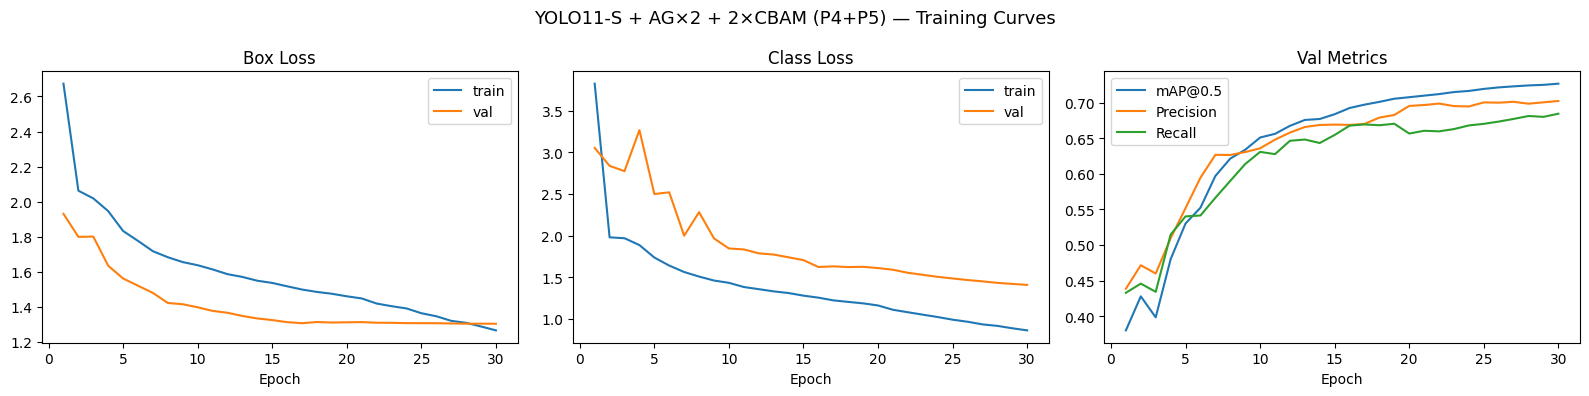

In [16]:
RUN_DIR = "/kaggle/working/runs/yolo11s_ag_cbam_p4p5"
BEST_PT = f"{RUN_DIR}/weights/best.pt"

df = pd.read_csv(f"{RUN_DIR}/results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO11-S + AG×2 + 2×CBAM (P4+P5) — Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/yolo11s_ag_cbam_p4p5_curves.png", dpi=120)
plt.show()

---
## 13. Evaluation — Eval A / B / C

In [17]:
try:
    del ag_cbam_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

eval_model = YOLO(BEST_PT)
lbl_test   = Path(f"{UNIFIED}/labels/test")
img_test   = Path(f"{UNIFIED}/images/test")
lbl_val    = Path(f"{UNIFIED}/labels/val")
img_val    = Path(f"{UNIFIED}/images/val")

def batched_fp_rate(model, hard_neg_imgs, batch_size=200):
    fp = 0
    for i in range(0, len(hard_neg_imgs), batch_size):
        preds = model.predict(source=hard_neg_imgs[i:i+batch_size],
                              imgsz=640, conf=0.25, device=0, verbose=False)
        fp += sum(1 for r in preds if len(r.boxes) > 0)
        torch.cuda.empty_cache()
    return fp, fp / len(hard_neg_imgs) if hard_neg_imgs else 0

def get_hard_negs(img_dir, lbl_dir):
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in lbl_dir.glob("*.txt")
        if lbl.read_text().strip() == ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

VRAM free: 15.3 GB ✅


In [18]:
print("── EVAL A: D-Fire Test Set ────────────────────────────────────")
metrics_A = eval_model.val(
    data="/kaggle/working/data.yaml", split="test",
    imgsz=640, batch=8, device=0,
    plots=True, project=RUN_DIR, name="eval_A_dfire_test", exist_ok=True,
)
map50_A, map5095_A = metrics_A.box.map50, metrics_A.box.map
prec_A,  rec_A     = metrics_A.box.mp,    metrics_A.box.mr
fp_A, fp_rate_A    = batched_fp_rate(eval_model, get_hard_negs(img_test, lbl_test))
print(f"  mAP@0.5 : {map50_A:.4f} | Recall : {rec_A:.4f} | FP Rate : {fp_rate_A:.4f}")
for i, cls in enumerate(["smoke","fire"]):
    print(f"  AP50 {cls:6s}: {metrics_A.box.ap50[i]:.4f}")

── EVAL A: D-Fire Test Set ────────────────────────────────────
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_ag_cbam_p4p5 summary (fused): 129 layers, 9,619,338 parameters, 0 gradients, 22.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9.0±5.6 MB/s, size: 102.6 KB)
val: Scanning /kaggle/working/unified_dataset/labels/test... 3754 images, 2005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3754/3754 764.8it/s 4.9s
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11243.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11244.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11245.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11313.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11315.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unif

In [19]:
print("── EVAL B: Combined Val Set ───────────────────────────────────")
torch.cuda.empty_cache()
metrics_B = eval_model.val(
    data="/kaggle/working/data.yaml", split="val",
    imgsz=640, batch=8, device=0,
    plots=True, project=RUN_DIR, name="eval_B_combined_val", exist_ok=True,
)
map50_B, map5095_B = metrics_B.box.map50, metrics_B.box.map
prec_B,  rec_B     = metrics_B.box.mp,    metrics_B.box.mr
fp_B, fp_rate_B    = batched_fp_rate(eval_model, get_hard_negs(img_val, lbl_val))
print(f"  mAP@0.5 : {map50_B:.4f} | Recall : {rec_B:.4f} | FP Rate : {fp_rate_B:.4f}")

── EVAL B: Combined Val Set ───────────────────────────────────
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2057.4±841.9 MB/s, size: 187.1 KB)
val: Scanning /kaggle/working/unified_dataset/labels/val.cache... 7025 images, 2129 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7025/7025 2.7Git/s 0.0s
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07536.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07539.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07561.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 879/879 13.3it/s 1:06
                   all       7025       7079      0.705      0.683      0.727      0.416
                 smoke       4733       5668      0.699      0.727      0.738      0.446
          

In [20]:
print("── EVAL C: PyroNear Val (tower cameras) ───────────────────────")
pyro_val_imgs = sorted(img_val.glob("pyro_*.jpg"))
pyro_val_lbls = [lbl_val / p.with_suffix(".txt").name for p in pyro_val_imgs]
pyro_pos      = sum(1 for l in pyro_val_lbls if l.exists() and l.read_text().strip())
pyro_neg      = sum(1 for l in pyro_val_lbls if l.exists() and not l.read_text().strip())
print(f"  Positives: {pyro_pos} | Hard negatives: {pyro_neg}")

tp_C = fp_C = fn_C = 0
for i in range(0, len(pyro_val_imgs), 200):
    chunk_imgs = [str(p) for p in pyro_val_imgs[i:i+200]]
    chunk_lbls = pyro_val_lbls[i:i+200]
    preds = eval_model.predict(source=chunk_imgs, imgsz=640,
                               conf=0.25, device=0, verbose=False)
    for pred, lbl_path in zip(preds, chunk_lbls):
        has_gt  = lbl_path.exists() and lbl_path.read_text().strip() != ""
        has_det = len(pred.boxes) > 0
        if     has_gt and     has_det: tp_C += 1
        elif   has_gt and not has_det: fn_C += 1
        elif not has_gt and   has_det: fp_C += 1
    torch.cuda.empty_cache()

fp_rate_C = fp_C / pyro_neg if pyro_neg else 0
recall_C  = tp_C / pyro_pos if pyro_pos else 0
print(f"  TP: {tp_C} | FP: {fp_C} | FN: {fn_C}")
print(f"  FP Rate: {fp_rate_C:.4f} ({fp_rate_C*100:.1f}%) | Recall: {recall_C:.4f} ({recall_C*100:.1f}%)")

── EVAL C: PyroNear Val (tower cameras) ───────────────────────
  Positives: 3345 | Hard negatives: 754
  TP: 3056 | FP: 433 | FN: 289
  FP Rate: 0.5743 (57.4%) | Recall: 0.9136 (91.4%)


---
## 14. Results Summary & Save

In [21]:
print("\n" + "="*65)
print(" RESULTS — YOLO11-S + AG×2 + 2×CBAM (P4+P5)")
print("="*65)
print(f"  {'Eval':<38} {'mAP@0.5':>8} {'Prec':>8} {'Rec':>8} {'FP Rate':>8}")
print(f"  {'-'*65}")
print(f"  {'A: D-Fire test  (cross-dataset)':<38} {map50_A:>8.4f} {prec_A:>8.4f} {rec_A:>8.4f} {fp_rate_A:>8.4f}")
print(f"  {'B: Combined val (all datasets)':<38} {map50_B:>8.4f} {prec_B:>8.4f} {rec_B:>8.4f} {fp_rate_B:>8.4f}")
print(f"  {'C: PyroNear val (tower only)':<38} {'—':>8} {'—':>8} {recall_C:>8.4f} {fp_rate_C:>8.4f}")
print("="*65)

print("\n── Ablation Table Context ──────────────────────────────────────────────")
ablation = [
    ("Baseline",             0.7653, 0.6835, 1.70, 0.7344, 0.8852, 0.6074),
    ("1×CBAM SPPF",          0.7550, 0.6736, 2.19, 0.7308, 0.9046, 0.6008),
    ("3×CBAM Neck",          0.7409, 0.6708, 1.20, 0.7200, 0.8251, 0.4231),
    ("4×CBAM (SPPF+3×Neck)", 0.7574, 0.6873, 2.19, 0.7328, 0.9136, 0.5889),
    ("2×CBAM (SPPF+P4)",     0.7655, 0.6931, 1.85, 0.7306, 0.8957, 0.5915),
    ("AG Skips (#2)",        0.7515, 0.6804, 1.05, 0.7236, 0.8921, 0.5623),
    ("CA+CBAM (#4)",         0.7583, 0.6895, 1.75, 0.7310, 0.9157, 0.6154),
    ("DCT (#3)",             0.7652, 0.6853, 1.75, 0.7333, 0.9133, 0.6167),
    ("DCT+AG",               0.7470, 0.6713, 1.90, 0.7250, 0.9205, 0.5849),
    ("DCT+AG+3×Neck",        0.7489, 0.6858, 2.04, 0.7203, 0.8873, 0.5875),
    ("2×CBAM (P4+P5)",       0.0000, 0.0000, 0.00, 0.0000, 0.0000, 0.0000),
]
print(f"  {'Config':<28} {'mAP-D':>7} {'Rec-D':>7} {'FP-D':>6} {'mAP-C':>7} {'Rec-P':>7} {'FP-P':>6}")
print(f"  {'-'*68}")
for row in ablation:
    name, ma, rc, fp, mc, rp, fpp = row
    print(f"  {name:<28} {ma:>7.4f} {rc:>7.4f} {fp:>5.1f}% {mc:>7.4f} {rp:>7.4f} {fpp*100:>5.1f}%")
print(f"  {'─'*68}")
print(f"  {'AG×2 + CBAM P4+P5 (THIS RUN)':<28} {map50_A:>7.4f} {rec_A:>7.4f} {fp_rate_A*100:>5.1f}% {map50_B:>7.4f} {recall_C:>7.4f} {fp_rate_C*100:>5.1f}%")

results = {
    "model"                   : "YOLO11-S + AG×2 + 2×CBAM (P4+P5)",
    "train_data"              : "unified (55,698)",
    "params"                  : "~9.4M + AG×2 + CBAM×2",
    "mAP50_dfire_test"        : round(float(map50_A),    4),
    "mAP5095_dfire_test"      : round(float(map5095_A),  4),
    "precision_dfire_test"    : round(float(prec_A),     4),
    "recall_dfire_test"       : round(float(rec_A),      4),
    "fp_rate_dfire_test"      : round(float(fp_rate_A),  4),
    "ap50_smoke_dfire"        : round(float(metrics_A.box.ap50[0]), 4),
    "ap50_fire_dfire"         : round(float(metrics_A.box.ap50[1]), 4),
    "mAP50_combined_val"      : round(float(map50_B),    4),
    "mAP5095_combined_val"    : round(float(map5095_B),  4),
    "precision_combined_val"  : round(float(prec_B),     4),
    "recall_combined_val"     : round(float(rec_B),      4),
    "fp_rate_combined_val"    : round(float(fp_rate_B),  4),
    "ap50_smoke_combined"     : round(float(metrics_B.box.ap50[0]), 4),
    "ap50_fire_combined"      : round(float(metrics_B.box.ap50[1]), 4),
    "recall_pyronear_val"     : round(float(recall_C),   4),
    "fp_rate_pyronear_val"    : round(float(fp_rate_C),  4),
    "tp_pyronear"             : int(tp_C),
    "fp_pyronear"             : int(fp_C),
    "fn_pyronear"             : int(fn_C),
}

results_csv = "/kaggle/working/yolo11s_ag_cbam_p4p5_results.csv"
pd.DataFrame([results]).to_csv(results_csv, index=False)
print(f"\nResults saved → {results_csv} ✅")


 RESULTS — YOLO11-S + AG×2 + 2×CBAM (P4+P5)
  Eval                                    mAP@0.5     Prec      Rec  FP Rate
  -----------------------------------------------------------------
  A: D-Fire test  (cross-dataset)          0.7521   0.7569   0.6782   0.0244
  B: Combined val (all datasets)           0.7272   0.7052   0.6833   0.2085
  C: PyroNear val (tower only)                  —        —   0.9136   0.5743

── Ablation Table Context ──────────────────────────────────────────────
  Config                         mAP-D   Rec-D   FP-D   mAP-C   Rec-P   FP-P
  --------------------------------------------------------------------
  Baseline                      0.7653  0.6835   1.7%  0.7344  0.8852  60.7%
  1×CBAM SPPF                   0.7550  0.6736   2.2%  0.7308  0.9046  60.1%
  3×CBAM Neck                   0.7409  0.6708   1.2%  0.7200  0.8251  42.3%
  4×CBAM (SPPF+3×Neck)          0.7574  0.6873   2.2%  0.7328  0.9136  58.9%
  2×CBAM (SPPF+P4)              0.7655  0.6931   

In [22]:
shutil.make_archive("/kaggle/working/yolo11s_ag_cbam_p4p5_full", "zip",
                    "/kaggle/working/runs/yolo11s_ag_cbam_p4p5")
print("Full run directory zipped → yolo11s_ag_cbam_p4p5_full.zip ✅")

Full run directory zipped → yolo11s_ag_cbam_p4p5_full.zip ✅


In [23]:
import shutil
import os

print("── Starting Final Cleanup ──────────────────────────")
directories_to_delete = [
    "/kaggle/working/unified_dataset",
    "/kaggle/working/pyro_yolo",
    "/kaggle/working/nemo_yolo"
]

for dir_path in directories_to_delete:
    if os.path.exists(dir_path):
        print(f"Deleting {dir_path}...")
        shutil.rmtree(dir_path)

print("Cleanup complete! Your Kaggle output will be lightweight. ✅")

── Starting Final Cleanup ──────────────────────────
Deleting /kaggle/working/unified_dataset...
Deleting /kaggle/working/pyro_yolo...
Deleting /kaggle/working/nemo_yolo...
Cleanup complete! Your Kaggle output will be lightweight. ✅
